# HER2-SPAND vs. measured ERBB2 — PBCP HER2-low / HER2-high

Per-patient HER2-SPAND (Moran's I on the cancer-restricted ErbB-pathway
signature; see [notebook 01](01_spand_pipeline_example.ipynb)) is compared
to measured bulk ERBB2 expression as a predictor of treatment response in
the PBCP cohort. The question: does HER2-SPAND carry signal **beyond**
measured ERBB2 — and specifically, does it help in the HER2-low half of the
cohort, where measured ERBB2 is less informative on its own?

This notebook uses **only precomputed per-patient scores** — no inline
pipeline computation. Computing the per-patient HER2-SPAND across the full
PBCP cohort requires the full Path2Space prediction pipeline (companion
repo) plus per-spot GSEA upstream; notebook 01 demonstrates the pipeline
on one slide.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score

## Load the per-patient scores

One row per PBCP patient: response (1 = pCR, 0 = RD), measured ERBB2 (bulk
log2 TPM), and HER2-SPAND (the cancer-restricted ErbB-pathway score from
the notebook-01 pipeline, computed upstream).

In [2]:
pbcp = pd.read_parquet("../data/pbcp_her2_scores.parquet")
print(f"{len(pbcp)} patients with all three values")
print("response counts:", pbcp['response'].value_counts().to_dict())
pbcp.head()

18 patients with all three values
response counts: {1: 11, 0: 7}


,slide_name,response,measured_ERBB2_log2_tpm,her2_spand
0,732243,1,11.270,-5.230656
1,732244,1,9.939,-4.534240
2,732250,0,11.512,-6.605669
3,732796,1,8.893,-9.573676
4,732799,1,10.191,-3.577716


## HER2-low vs HER2-high split

Split the cohort by **measured** ERBB2 (bulk log2 TPM) at the median. With
only 9 patients per stratum the bootstrap CIs are wide, but the per-stratum
comparison still shows whether the two scores carry the same information or
trade off across the two halves.

In [3]:
med = pbcp['measured_ERBB2_log2_tpm'].median()
pbcp['stratum'] = np.where(pbcp['measured_ERBB2_log2_tpm'] < med, 'HER2-low', 'HER2-high')
print(pbcp.groupby('stratum').agg(n=('response','count'), n_pCR=('response','sum')).to_string())

           n  n_pCR
stratum            
HER2-high  9      7
HER2-low   9      4


## AUC with bootstrap 95% CI

In [4]:
def bootstrap_auc(y_true, y_score, n_boot=1000, seed=0):
    rng = np.random.default_rng(seed)
    base = roc_auc_score(y_true, y_score)
    boots = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true.iloc[idx])) < 2:
            continue
        boots.append(roc_auc_score(y_true.iloc[idx], y_score.iloc[idx]))
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return base, lo, hi

rows = []
for stratum_name, d in [("all patients", pbcp),
                        ("HER2-low (below median)",  pbcp[pbcp.stratum == 'HER2-low']),
                        ("HER2-high (above median)", pbcp[pbcp.stratum == 'HER2-high'])]:
    for score_name, col in [("measured ERBB2",  "measured_ERBB2_log2_tpm"),
                            ("HER2-SPAND",      "her2_spand")]:
        auc, lo, hi = bootstrap_auc(d['response'], d[col])
        rows.append({"stratum": stratum_name, "score": score_name,
                     "auc": auc, "ci_lo": lo, "ci_hi": hi, "n": len(d)})
result = pd.DataFrame(rows)
result.round(3)

,stratum,score,auc,ci_lo,ci_hi,n
0,all patients,measured ERBB2,0.714,0.389,0.950,18
1,all patients,HER2-SPAND,0.688,0.378,0.929,18
2,HER2-low (below median),measured ERBB2,0.700,0.200,1.000,9
3,HER2-low (below median),HER2-SPAND,0.600,0.143,1.000,9
4,HER2-high (above median),measured ERBB2,0.429,0.000,1.000,9
5,HER2-high (above median),HER2-SPAND,0.786,0.333,1.000,9


## Plot — AUC with 95% CI per stratum

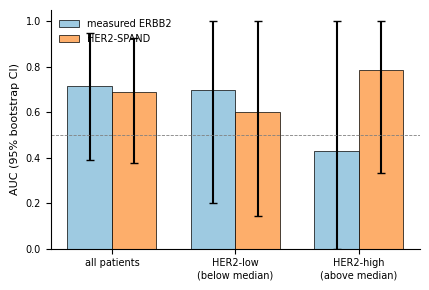

In [5]:
fig, ax = plt.subplots(figsize=(4.4, 3.0))
strata = ["all patients", "HER2-low (below median)", "HER2-high (above median)"]
scores = ["measured ERBB2", "HER2-SPAND"]
palette = {"measured ERBB2": "#9ecae1", "HER2-SPAND": "#fdae6b"}
x = np.arange(len(strata)); w = 0.36
for i, s in enumerate(scores):
    d = result[result.score == s].set_index('stratum').loc[strata]
    offsets = x + (i - 0.5) * w
    err = np.vstack([d['auc'] - d['ci_lo'], d['ci_hi'] - d['auc']])
    ax.bar(offsets, d['auc'], width=w, yerr=err, capsize=3,
           color=palette[s], edgecolor='black', linewidth=0.5, label=s)
ax.axhline(0.5, color='grey', lw=0.6, ls='--')
ax.set_xticks(x)
ax.set_xticklabels([s.replace(' (', '\n(') for s in strata], fontsize=7)
ax.set_ylabel('AUC (95% bootstrap CI)', fontsize=8)
ax.set_ylim(0, 1.05)
ax.tick_params(axis='y', labelsize=7)
ax.legend(fontsize=7, frameon=False, loc='upper left')
sns.despine(); fig.tight_layout(); plt.show()

## Takeaway

Across all 18 patients, measured ERBB2 and HER2-SPAND give comparable AUC
(0.71 and 0.69 respectively), but they carry different information: HER2-SPAND
captures the **spatial pattern** of the ErbB-pathway signature inside the
cancer compartment of the tissue, whereas measured ERBB2 is bulk expression.
The per-stratum split (9 patients on each side, so wide 95% CIs) suggests the
two scores trade off across the HER2-low and HER2-high halves of the cohort —
in this small subset HER2-SPAND adds the most where measured ERBB2 sits near
chance. A larger cohort would be needed to characterize where each score is
most informative.